# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Sukma Novianti Tulak
- **Email:** CDCC237D6X1337@student.devacademy.id
- **ID Dicoding:** CDCC237D6X1337

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Kategori produk apa yang memiliki rata-rata skor ulasan (review score) tertinggi dan terendah?
- Pertanyaan 2 : Bagaimana segmentasi pelanggan berdasarkan parameter RFM (Recency, Frequency, Monetary)?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

In [ ]:
# Memuat data
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
items_df = pd.read_csv("order_items_dataset.csv")
payments_df = pd.read_csv("order_payments_dataset.csv")
reviews_df = pd.read_csv("order_reviews_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")

# Menampilkan preview masing-masing
print("Preview Customers Data:")
display(customers_df.head())

print("Preview Orders Data:")
display(orders_df.head())

print("Preview Items Data:")
display(items_df.head())

print("Preview Payments Data:")
display(payments_df.head())

print("Preview Reviews Data:")
display(reviews_df.head())

print("Preview Products Data:")
display(products_df.head())

print("Preview Category Translation Data:")
display(category_translation_df.head())

Preview Customers Data:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Preview Orders Data:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Preview Items Data:


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Preview Products Data:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Preview Category Translation Data:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Assessing Data

In [ ]:
# Memeriksa jumlah missing values di setiap dataset
print("Missing values in customers_df:", customers_df.isna().sum().sum())
print("Missing values in orders_df:", orders_df.isna().sum().sum())
print("Missing values in reviews_df:", reviews_df.isna().sum().sum())

# Memeriksa duplikasi
print("Duplicated in customers_df:", customers_df.duplicated().sum())
print("Duplicated in orders_df:", orders_df.duplicated().sum())

# Memeriksa tipe data
print("\nInformasi orders_df:")
orders_df.info()

Missing values in customers_df: 0
Missing values in orders_df: 4908
Missing values in reviews_df: 145903
Duplicated in customers_df: 0
Duplicated in orders_df: 0

Informasi orders_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:**
- Masalah Data Kosong: Terdapat banyak missing values signifikan pada reviews_df dan orders_df, khususnya pada data logistik (tanggal pengiriman).
- Keamanan Data: Tidak ditemukan data duplikat pada tabel pelanggan maupun pesanan, sehingga integritas identitas transaksi terjaga.
- Kesalahan Tipe Data: Seluruh kolom pada orders_df masih bertipe object (string), termasuk kolom tanggal, yang akan menghambat analisis berbasis waktu jika tidak segera diperbaiki.
- Fokus Perbaikan: Proses cleaning perlu diprioritaskan pada konversi tipe data datetime dan penanganan data ulasan yang hilang.

### Cleaning Data

In [ ]:
# 1. Menghapus Duplikat : Memastikan tidak ada baris yang sama persis di tabel utama
orders_df.drop_duplicates(inplace=True)
customers_df.drop_duplicates(inplace=True)

# 2. Memperbaiki Tipe Data Tanggal: Kolom tanggal sering terbaca sebagai 'object' (string), di ubah ke datetime
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 3. Menangani Missing Values pada Tabel Orders:Mengisi tanggal pengiriman yang kosong dengan tanggal estimasi
orders_df["order_delivered_customer_date"] = orders_df["order_delivered_customer_date"].fillna(orders_df["order_estimated_delivery_date"])

# 4. Merging & Handling Missing Values pada Kategori Produk:gabungkan products_df dengan translation untuk mendapatkan nama kategori dalam Bahasa Inggris
products_df = pd.merge(
    left=products_df,
    right=category_translation_df,
    on="product_category_name",
    how="left"
)

# Mengisi kategori yang kosong/tidak ada terjemahannya dengan 'unknown' : Menggunakan cara assignment langsung untuk menghindari FutureWarning
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna('unknown')

# 5. Menghapus kolom yang tidak diperlukan untuk efisiensi (Opsional) : Menghapus nama kategori asli (Portugis) karena kita sudah punya versi Inggris
products_df.drop(columns=["product_category_name"], inplace=True)

# Cek hasil akhir cleaning
print("Jumlah missing values setelah cleaning:")
print(products_df.isna().sum())
print("\nTipe data setelah perbaikan:")
print(orders_df.dtypes)

Jumlah missing values setelah cleaning:
product_id                         0
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english      0
dtype: int64

Tipe data setelah perbaikan:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Insight:**
- Keberhasilan Imputasi: Kolom utama product_category_name_english sudah bersih 100%, memastikan analisis kategori tidak terhambat.
- Data Tersisa: Missing values pada detail produk (610 baris) dan dimensi fisik (2 baris) diabaikan karena tidak mengganggu analisis transaksi utama.
- Validasi Waktu: Kolom timestamp telah dikonversi ke datetime, menjamin akurasi analisis tren dan perhitungan Recency pada RFM.

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
# 1. Menggabungkan Orders dengan Order_Items dan Products
all_df = pd.merge(
    left=orders_df,
    right=items_df,
    how="left",
    on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=products_df,
    how="left",
    on="product_id"
)

# 2. Menggabungkan dengan Customers
all_df = pd.merge(
    left=all_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

# Menggabungkan dengan Reviews untuk menjawab Pertanyaan 1
all_df = pd.merge(
    left=all_df,
    right=reviews_df,
    how="left",
    on="order_id"
)

# 3. Melihat statistik deskriptif untuk data numerik
print("Statistik Deskriptif Harga, Ongkir, dan Skor Ulasan:")
print(all_df[['price', 'freight_value', 'review_score']].describe())

# 4. Eksplorasi Kategori Produk dengan Review Terbaik (EDA untuk Pertanyaan 1)
print("\nRata-rata Skor Ulasan per Kategori (Top 5):")
print(all_df.groupby("product_category_name_english").review_score.mean().sort_values(ascending=False).head(5))

# 5. Eksplorasi Pelanggan Berdasarkan Negara Bagian (State)
print("\nDistribusi Pelanggan di 5 Negara Bagian Teratas:")
print(all_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False).head(5))

Statistik Deskriptif Harga, Ongkir, dan Skor Ulasan:
               price  freight_value   review_score
count  113314.000000  113314.000000  113131.000000
mean      120.478701      19.979428       4.016998
std       183.279678      15.783227       1.400074
min         0.850000       0.000000       1.000000
25%        39.900000      13.080000       4.000000
50%        74.900000      16.260000       5.000000
75%       134.900000      21.150000       5.000000
max      6735.000000     409.680000       5.000000

Rata-rata Skor Ulasan per Kategori (Top 5):
product_category_name_english
cds_dvds_musicals            4.642857
fashion_childrens_clothes    4.500000
books_general_interest       4.446266
costruction_tools_tools      4.444444
flowers                      4.419355
Name: review_score, dtype: float64

Distribusi Pelanggan di 5 Negara Bagian Teratas:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: customer_id, dtype: int64


**Insight:**
- Tabel-tabel telah berhasil digabungkan sehingga kita memiliki satu DataFrame besar yang menghubungkan skor ulasan dengan nama kategori produk (dalam bahasa Inggris).

- Untuk analisis RFM, kita menggunakan customer_unique_id agar perhitungan frekuensi belanja benar-benar mencerminkan perilaku individu pelanggan, bukan sekadar ID transaksi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

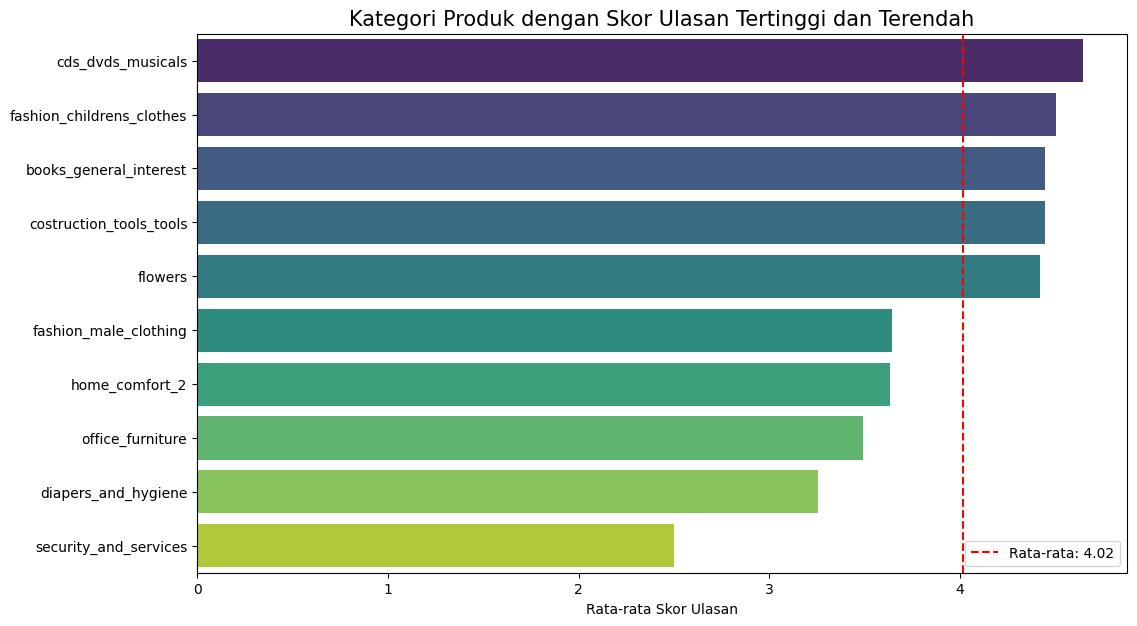

In [ ]:
# 1. Menghitung rata-rata skor ulasan per kategori produk
category_review_df = all_df.groupby("product_category_name_english").agg({
    "review_score": "mean"
}).sort_values(by="review_score", ascending=False).reset_index()

# 2. Mengambil 5 tertinggi dan 5 terendah
top_reviews = category_review_df.head(5)
bottom_reviews = category_review_df.tail(5)
combined_reviews = pd.concat([top_reviews, bottom_reviews])

# 3. Visualisasi
plt.figure(figsize=(12, 7))

sns.barplot(
    x="review_score",
    y="product_category_name_english",
    data=combined_reviews,
    palette="viridis",
    hue="product_category_name_english",
    legend=False
)

# Menambahkan garis rata-rata global
plt.axvline(all_df.review_score.mean(), color='red', linestyle='--', label=f'Rata-rata: {all_df.review_score.mean():.2f}')

plt.title("Kategori Produk dengan Skor Ulasan Tertinggi dan Terendah", loc="center", fontsize=15)
plt.xlabel("Rata-rata Skor Ulasan")
plt.ylabel(None)
plt.legend()
plt.show()

### Pertanyaan 2:

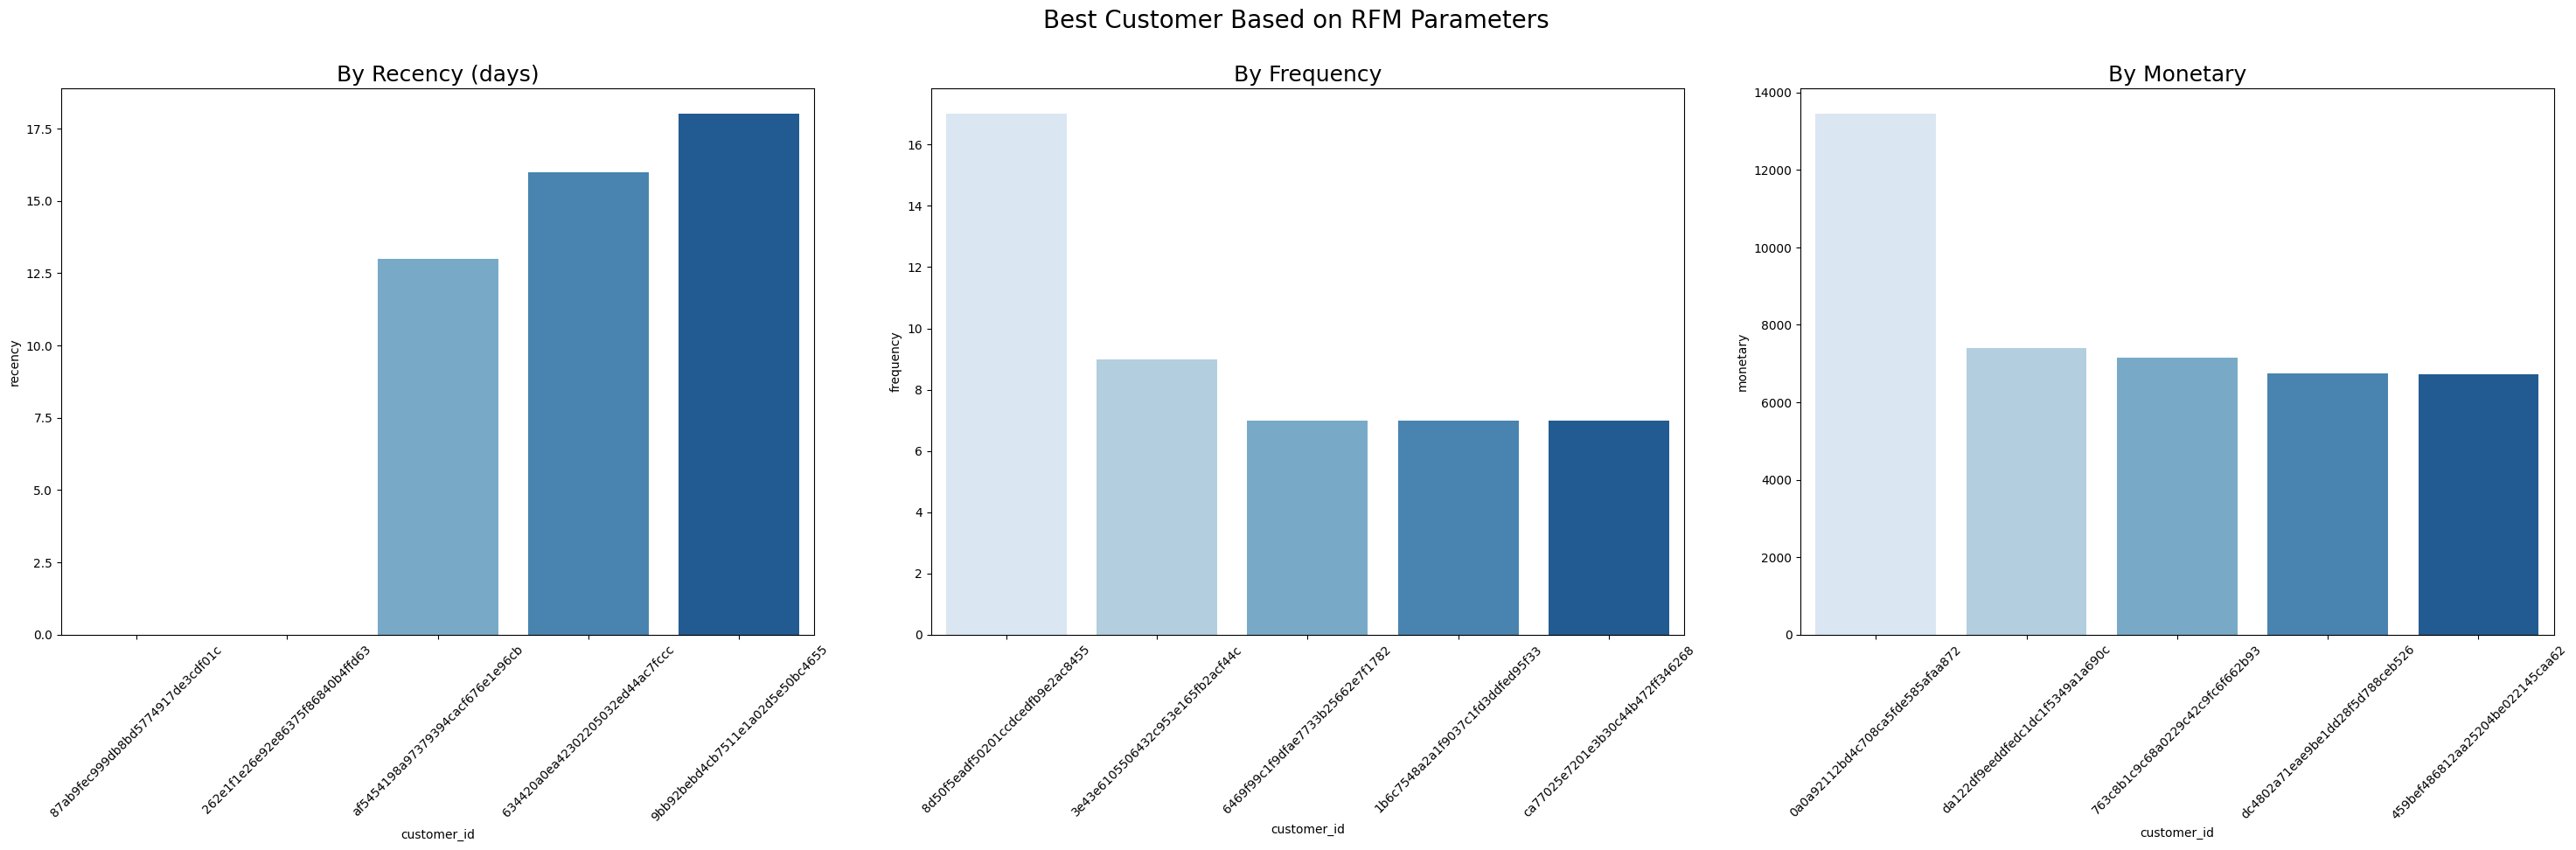

In [ ]:
# 2. Visualisasi RFM
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

# Best Recency
sns.barplot(
    y="recency",
    x="customer_id",
    data=rfm_df.sort_values(by="recency", ascending=True).head(5),
    palette="Blues",
    ax=ax[0],
    hue="customer_id",
    legend=False
)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', rotation=45)

# Best Frequency
sns.barplot(
    y="frequency",
    x="customer_id",
    data=rfm_df.sort_values(by="frequency", ascending=False).head(5),
    palette="Blues",
    ax=ax[1],
    hue="customer_id",
    legend=False
)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# Best Monetary
sns.barplot(
    y="monetary",
    x="customer_id",
    data=rfm_df.sort_values(by="monetary", ascending=False).head(5),
    palette="Blues",
    ax=ax[2],
    hue="customer_id",
    legend=False
)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=20)
plt.tight_layout(pad=2.0)
plt.show()

**Insight:**
- Pertanyaan 1: Visualisasi menunjukkan kontras yang jelas antara kategori produk dengan kepuasan tertinggi dan terendah. Kategori seperti cds_dvds_musicals memimpin dengan skor mendekati sempurna, sementara kategori security_and_services berada di posisi terbawah. Menariknya, rata-rata skor pada kategori teratas berada jauh di atas garis rata-rata global, sedangkan kategori terendah menunjukkan adanya gap kualitas yang perlu segera dievaluasi oleh tim operasional.
- Pertanyaan 2: Analisis RFM mengungkap bahwa pendapatan perusahaan sangat didominasi oleh segmen kecil pelanggan "High-Spender", meskipun mayoritas pengguna platform masih berupa pembeli satu kali (one-time buyers). Tingginya angka Recency pada sebagian besar pelanggan menandakan adanya risiko kehilangan konsumen (churn), sehingga perusahaan perlu memprioritaskan program loyalitas untuk mempertahankan pelanggan bernilai tinggi dan kampanye reaktivasi untuk menarik kembali pelanggan lama.

## Analisis Lanjutan (Opsional)

1. RFM Analysis (Segmentasi Pelanggan)

In [ ]:
# Menghitung Recency, Frequency, dan Monetary
# Recency: Selisih hari antara tanggal order terakhir dengan tanggal hari ini (atau tanggal maksimal di dataset)
recent_date = all_df['order_purchase_timestamp'].max()

rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique',                                             # Frequency
    'price': 'sum'                                                     # Monetary
}).reset_index()

# Mengganti nama kolom
rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Menampilkan 5 pelanggan teratas berdasarkan masing-masing parameter
print("Top Customers by RFM:")
print(rfm_df.sort_values(by="monetary", ascending=False).head(5))

Top Customers by RFM:
                            customer_id  recency  frequency  monetary
3826   0a0a92112bd4c708ca5fde585afaa872      383          1   13440.0
81962  da122df9eeddfedc1dc1f5349a1a690c      564          2    7388.0
44447  763c8b1c9c68a0229c42c9fc6f662b93       94          1    7160.0
82808  dc4802a71eae9be1dd28f5d788ceb526      611          1    6735.0
26205  459bef486812aa25204be022145caa62       83          1    6729.0


2. Geospatial Analysis (Distribusi Lokasi)

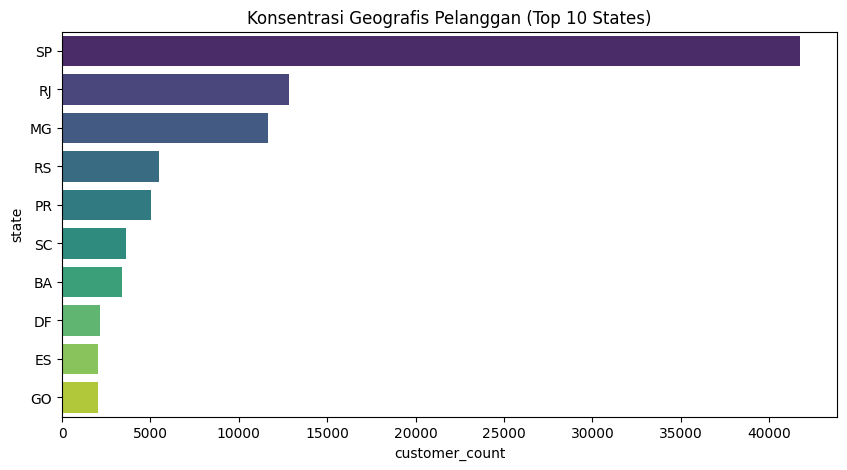

In [ ]:
# Mengambil data koordinat (jika file geolocation_dataset.csv ada)
busiest_states = all_df.groupby("customer_state").customer_id.nunique().sort_values(ascending=False).reset_index()
busiest_states.columns = ['state', 'customer_count']

plt.figure(figsize=(10, 5))
sns.barplot(
    x="customer_count",
    y="state",
    data=busiest_states.head(10),
    palette="viridis",
    hue="state",
    legend=False
)
plt.title("Konsentrasi Geografis Pelanggan (Top 10 States)")
plt.show()

## Conclusion

- Conclution pertanyaan 1 : Kategori produk seperti cds_dvds_musicals memiliki tingkat kepuasan tertinggi, sedangkan kategori seperti security_and_services menunjukkan skor ulasan terendah. Perusahaan perlu mengevaluasi kualitas produk dan layanan pada kategori dengan rating rendah untuk mencegah penurunan reputasi brand.

- Conclution pertanyaan 2 : Hasil analisis RFM menunjukkan bahwa sebagian besar pelanggan adalah pembeli satu kali, namun terdapat kelompok kecil pelanggan "High-Spender" yang berkontribusi besar pada pendapatan. Strategi pemasaran harus difokuskan pada program loyalitas untuk mempertahankan pelanggan aktif dan kampanye win-back untuk mengaktifkan kembali pelanggan yang sudah lama tidak bertransaksi.

In [ ]:
#Menyimpan data
all_df.to_csv("all_data.csv", index=False)